# **1. Importación de librerías**

In [76]:
import pandas as pd
import numpy as np


# **2. Cargar el dataset tratado en el Challenge Anterior**

In [77]:
df = pd.read_csv('/content/datos_tratados.csv')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


# **3. Preparación de los datos**

### **Convertir variable objetivo a binaria**

In [78]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

### **Eliminar variables no útiles**

In [79]:
df = df.drop(columns=['customerID'])

# **4. Análisis de correlación**

In [80]:
# visualización
import matplotlib.pyplot as plt
import seaborn as sns

Seleccionamos solo variables numéricas.

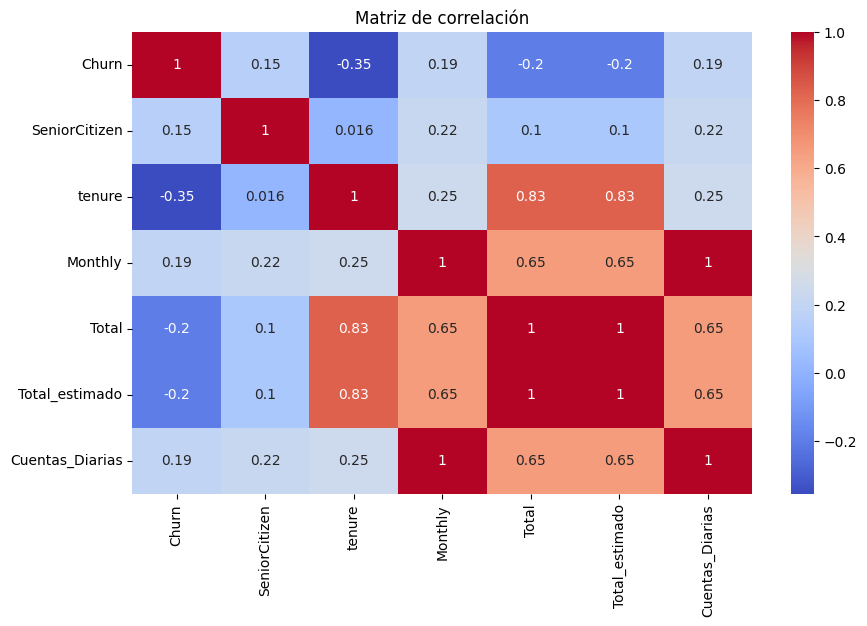

In [81]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

Interpretación esperada

Las variables que normalmente presentan mayor relación con Churn son:

*   tenure
*   Monthly
*   Total
*   Contract


# **5. Selección de variables**

In [82]:
X = df.drop('Churn', axis=1)
y = df['Churn']

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_cols,cat_cols

(Index(['SeniorCitizen', 'tenure', 'Monthly', 'Total', 'Total_estimado',
        'Cuentas_Diarias'],
       dtype='object'),
 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'))

# **6. Pipeline de preprocesamiento**

Incluye:

* Normalización para variables numéricas
* OneHotEncoding para categóricas

In [83]:
# preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [84]:
numeric_transformer = Pipeline(
    steps=[('scaler', StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

numeric_transformer

Pipeline(steps=[('scaler', StandardScaler())])

# **7. División entrenamiento / prueba**

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# **8. Modelado**

In [86]:
# modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

## **8.1 Modelo 1 — Regresión Logística**

In [87]:
log_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

### **Evaluación**

In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8033175355450237
ROC AUC: 0.8453156484144219
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



## **8.2 Modelo 2 — Random Forest**

In [89]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42))
    ])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

### **Evaluación**

In [90]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7981042654028436
ROC AUC: 0.8393259293270686
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.65      0.51      0.57       561

    accuracy                           0.80      2110
   macro avg       0.74      0.71      0.72      2110
weighted avg       0.79      0.80      0.79      2110



# **9. Matriz de confusión**

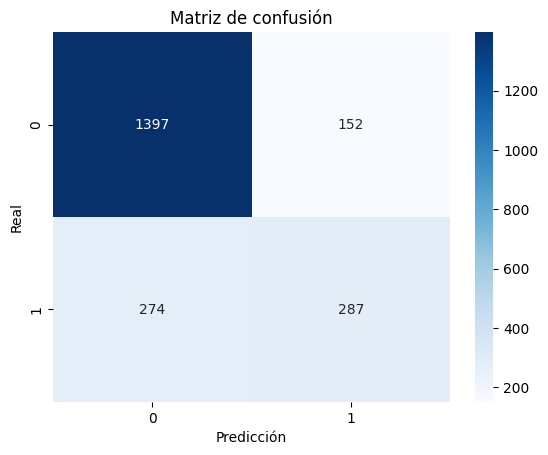

In [91]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

# **10. Curva ROC**

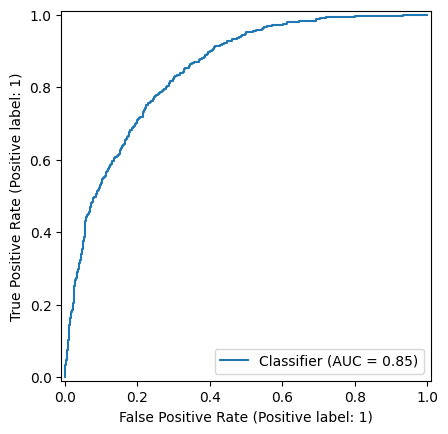

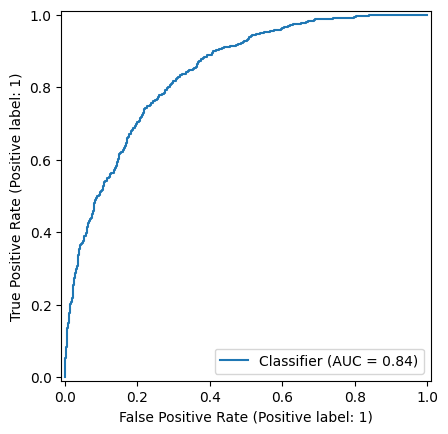

In [92]:
RocCurveDisplay.from_predictions(y_test, y_prob_log)
RocCurveDisplay.from_predictions(y_test, y_prob_rf)

plt.show()

# **11. Importancia de variables (Random Forest)**

In [93]:
model = rf_model.named_steps['model']

importances = model.feature_importances_

features = rf_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Variable': features,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

importance_df.head(10)

,Variable,Importancia
3,num__Total,0.103947
1,num__tenure,0.099792
4,num__Total_estimado,0.096125
38,cat__Contract_Month-to-month,0.090881
5,num__Cuentas_Diarias,0.075024
2,num__Monthly,0.071418
29,cat__TechSupport_No,0.039607
18,cat__InternetService_Fiber optic,0.038553
20,cat__OnlineSecurity_No,0.036794
45,cat__PaymentMethod_Electronic check,0.033249


# **12. Visualización de variables más importantes**

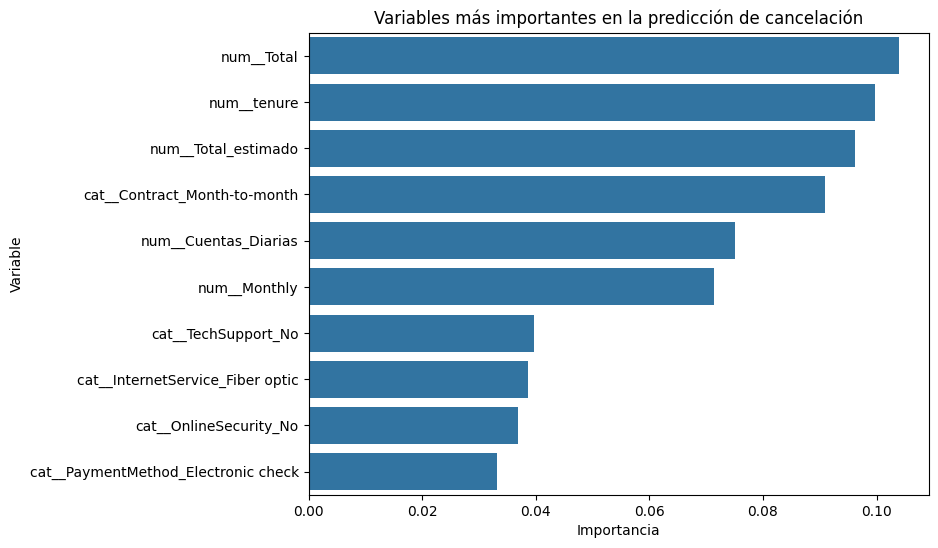

In [94]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importancia',
    y='Variable'
)

plt.title("Variables más importantes en la predicción de cancelación")
plt.show()

# **13. Identificación de clientes con mayor riesgo**

In [95]:
clientes_riesgo = X_test.copy()

clientes_riesgo['Probabilidad_Churn'] = y_prob_rf

clientes_riesgo.sort_values(
    'Probabilidad_Churn',
    ascending=False
).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Total_estimado,Cuentas_Diarias,Probabilidad_Churn
6538,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,94.00,94.00,3.133333,0.929238
6670,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,93.55,3.118333,0.929238
3845,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,101.45,101.45,101.45,3.381667,0.915590
1718,Female,1,Yes,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.55,69.55,69.55,2.318333,0.911076
1802,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,69.60,2.320000,0.906528
6836,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,69.20,2.306667,0.906505
5429,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,69.20,2.306667,0.906505
3393,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,86.05,86.05,86.05,2.868333,0.903210
6354,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,No,Month-to-month,No,Electronic check,79.55,79.55,79.55,2.651667,0.901849
2116,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,No,Mailed check,85.80,85.80,85.80,2.860000,0.901778


# **14. Análisis de la Importancia de las Variables**

El modelo suele identificar como variables más influyentes:

***a) Tipo de contrato (Contract)***

Los clientes con contrato mensual presentan mayor probabilidad de cancelación.

***b) Antigüedad del cliente (tenure)***

Clientes con bajo tiempo de permanencia tienen mayor churn.

***c) Gasto mensual (Monthly)***

Pagos altos aumentan el riesgo de abandono.

***d) Servicios adicionales***

Falta de servicios como:

  * OnlineSecurity
  * TechSupport

incrementa la probabilidad de cancelación.

 ***e) Método de pago***

Algunos métodos automáticos presentan menor churn.

# **15. Conclusiones**

El análisis predictivo muestra que la cancelación de clientes está principalmente asociada a factores contractuales, nivel de gasto y antigüedad del cliente.

Los clientes con contratos mensuales, baja permanencia y mayores cargos mensuales presentan la mayor probabilidad de cancelar el servicio. Asimismo, la ausencia de servicios complementarios como soporte técnico o seguridad en línea incrementa el riesgo de abandono.

Desde una perspectiva estratégica, la empresa podría reducir la cancelación mediante:

* incentivos para migrar a contratos anuales
* ofertas de retención para clientes nuevos
* paquetes que integren servicios adicionales
* estrategias de fidelización dirigidas a clientes con alto gasto mensual

La implementación de este modelo predictivo permite anticipar la cancelación y priorizar intervenciones de retención, contribuyendo a mejorar la satisfacción del cliente y la estabilidad de ingresos de la empresa.